<a href="https://colab.research.google.com/github/nikspatil0120/23102A0057_RProgramming/blob/main/R_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nikhil Patil

BE CMPN A 23102A0057

R Assignment 1

Reading the CSV using the tryCatch Block

In [ ]:
file_name <- "/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
air_data <- tryCatch(
{
  read.csv(file_name)
},
warning=function(w){
  print(paste("Warning:",w))
},
error=function(e){
  stop(paste("Error:",e$message))
}
)

Task 1: Inspecting The Dataset

In [ ]:
print("First Six Records")
head(air_data)

print("Structure of Dataset")
str(air_data)

cat("\nRows:", nrow(air_data), "\n")
cat("Columns:", ncol(air_data), "\n")

cat("\nMissing Values Present:", any(is.na(air_data)), "\n")
cat("Total Missing Values:", sum(is.na(air_data)), "\n")

[1] "First Six Records"


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,4,4,4,7,300,77,-0.7,1023.0,-18.8,0,NNW,4.4,Aotizhongxin
2,2,2013,3,1,1,8,8,4,7,300,77,-1.1,1023.2,-18.2,0,N,4.7,Aotizhongxin
3,3,2013,3,1,2,7,7,5,10,300,73,-1.1,1023.5,-18.2,0,NNW,5.6,Aotizhongxin
4,4,2013,3,1,3,6,6,11,11,300,72,-1.4,1024.5,-19.4,0,NW,3.1,Aotizhongxin
5,5,2013,3,1,4,3,3,12,12,300,72,-2.0,1025.2,-19.5,0,N,2.0,Aotizhongxin
6,6,2013,3,1,5,5,5,18,18,400,66,-2.2,1025.6,-19.6,0,N,3.7,Aotizhongxin


[1] "Structure of Dataset"
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aoti

Task 2: Difference between NA, NULL and NaN

In [ ]:
temperature <- c(28,30,NA,32)
missing_object <- NULL
undefined_value <- 0/0

cat("\nNA Example\n")
print(temperature)
print(is.na(temperature))

cat("\nNULL Example\n")
print(missing_object)
print(is.null(missing_object))

cat("\nNaN Example\n")
print(undefined_value)
print(is.nan(undefined_value))



NA Example
[1] 28 30 NA 32
[1] FALSE FALSE  TRUE FALSE

NULL Example
NULL
[1] TRUE

NaN Example
[1] NaN
[1] TRUE


Task 3 : Missing Values Summary

In [ ]:
missing_summary <- function(df)
{
    variables <- c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")

    summary_df <- data.frame(
        Variable=character(),
        Total_Records=integer(),
        Missing_Values=integer(),
        Missing_Percentage=numeric()
    )

    for(var in variables)
    {
        total <- nrow(df)
        missing <- sum(is.na(df[[var]]))
        percent <- round((missing/total)*100,2)

        summary_df <- rbind(summary_df,
                            data.frame(
                                Variable=var,
                                Total_Records=total,
                                Missing_Values=missing,
                                Missing_Percentage=percent
                            ))

        if(percent > 20)
        {
            warning(paste(var,"contains more than 20% missing values"))
        }
    }

    return(summary_df)
}

cat("\nMissing Summary\n")
summary_before <- missing_summary(air_data)
print(summary_before)


Missing Summary
  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


Task 4: Identify Invalid Numerical Results

In [ ]:
air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

cat("\nNumber of NA:",sum(is.na(air_data$pollution_ratio)),"\n")
cat("Number of NaN:",sum(is.nan(air_data$pollution_ratio)),"\n")
cat("Infinite Values:",sum(is.infinite(air_data$pollution_ratio)),"\n")

air_data$pollution_ratio[
    is.nan(air_data$pollution_ratio) |
    is.infinite(air_data$pollution_ratio)
] <- NA


Number of NA: 0 
Number of NaN: 0 
Infinite Values: 0 


Task 5: Handle Missing Numerical Values Using Loop

In [ ]:
numeric_variables <- c("PM2.5","PM10","SO2","NO2","TEMP","WSPM")

missing_before <- c()

for(var in numeric_variables)
{

    if(var %in% names(air_data))
    {

        before <- sum(is.na(air_data[[var]]))
        missing_before[var] <- before

        med <- median(air_data[[var]],na.rm=TRUE)

        air_data[[var]][is.na(air_data[[var]])] <- med

        after <- sum(is.na(air_data[[var]]))

        cat("\nVariable:",var,"\n")
        cat("Missing Before:",before,"\n")
        cat("Median Used:",med,"\n")
        cat("Missing After:",after,"\n")

    }

}




Variable: PM2.5 
Missing Before: 925 
Median Used: 58 
Missing After: 0 

Variable: PM10 
Missing Before: 718 
Median Used: 87 
Missing After: 0 

Variable: SO2 
Missing Before: 935 
Median Used: 9 
Missing After: 0 

Variable: NO2 
Missing Before: 1023 
Median Used: 53 
Missing After: 0 

Variable: TEMP 
Missing Before: 20 
Median Used: 14.5 
Missing After: 0 

Variable: WSPM 
Missing Before: 14 
Median Used: 1.4 
Missing After: 0 


Task 6: Handle Missing Categorical Values

In [ ]:
calculate_mode <- function(x)
{
    unique_values <- unique(x)

    unique_values <- unique_values[!is.na(unique_values)]

    unique_values[which.max(tabulate(match(x,unique_values)))]
}

before_wd <- sum(is.na(air_data$wd))

mode_value <- calculate_mode(air_data$wd)

air_data$wd[is.na(air_data$wd)] <- mode_value

after_wd <- sum(is.na(air_data$wd))

cat("\nWind Direction Mode:",mode_value,"\n")
cat("Missing Before:",before_wd,"\n")
cat("Missing After:",after_wd,"\n")


Wind Direction Mode: NE 
Missing Before: 81 
Missing After: 0 


Task 7: Error Handling Function

In [ ]:
clean_variable <- function(df,varname)
{

tryCatch({

if(!(varname %in% names(df)))
{
stop("Variable does not exist.")
}

if(!is.numeric(df[[varname]]))
{
stop("Variable is not numerical.")
}

if(all(is.na(df[[varname]])))
{
stop("Variable contains only missing values.")
}

med <- median(df[[varname]],na.rm=TRUE)

if(is.na(med))
{
stop("Median cannot be calculated.")
}

df[[varname]][is.na(df[[varname]])] <- med

return(df[[varname]])

},

error=function(e)
{
cat("Error:",e$message,"\n")
})

}

cat("\nTesting clean_variable()\n")

result1 <- clean_variable(air_data, "PM2.5")
cat("PM2.5 cleaned successfully.\n")

clean_variable(air_data, "wd")
clean_variable(air_data, "ABC")


Testing clean_variable()
PM2.5 cleaned successfully.
Error: Variable is not numerical. 
Error: Variable does not exist. 


Task 8: Comparison Table

In [ ]:
variables <- c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")

missing_after <- c()

for(v in variables)
{
missing_after[v] <- sum(is.na(air_data[[v]]))
}

comparison <- data.frame(

Variable=variables,

Missing_Before=c(
summary_before$Missing_Values
),

Missing_After=as.numeric(missing_after),

Values_Replaced=
summary_before$Missing_Values-as.numeric(missing_after)

)

cat("\nComparison Table\n")
print(comparison)

cat("\nInterpretation\n")

if(all(comparison$Missing_After==0))
{
cat("All selected missing values were successfully handled.\n")
}else
{
cat("Some missing values still remain.\n")
}


Comparison Table
  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

Interpretation
All selected missing values were successfully handled.


Task 9: Visualization

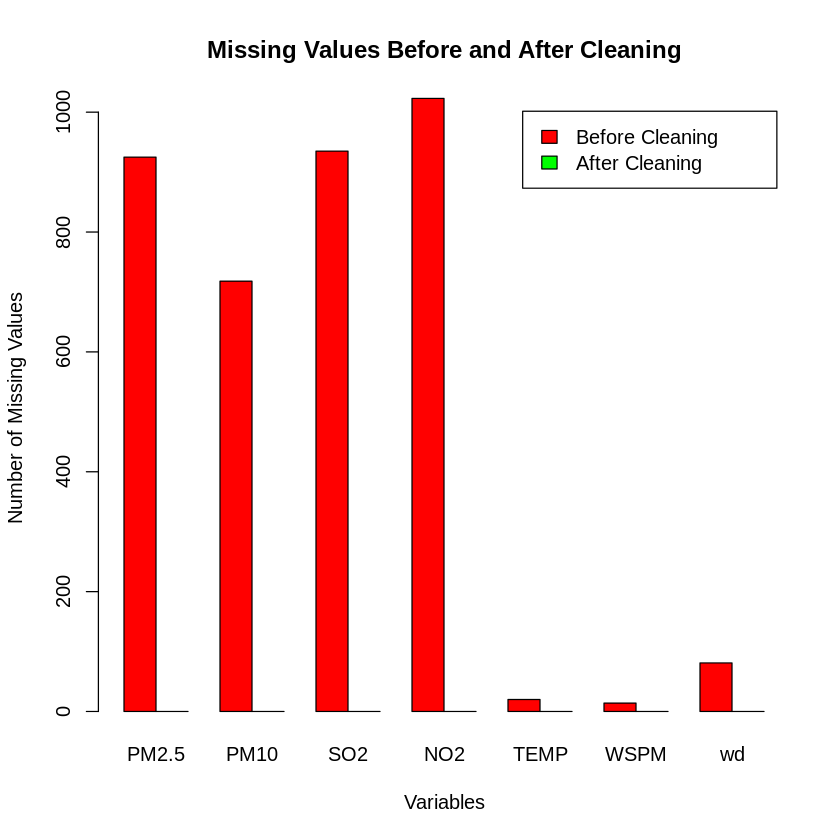

In [ ]:
before <- comparison$Missing_Before
after <- comparison$Missing_After

barplot(
rbind(before,after),
beside=TRUE,
col=c("red","green"),
names.arg=comparison$Variable,
main="Missing Values Before and After Cleaning",
xlab="Variables",
ylab="Number of Missing Values",
legend.text=c("Before Cleaning","After Cleaning")
)

Task 10: Export Cleaned Dataset

In [ ]:
write.csv(
air_data,
"cleaned_air_quality_data.csv",
row.names=FALSE
)

cat("\nCleaned dataset exported successfully.\n")


Cleaned dataset exported successfully.
